---
---
# Netflix Content Strategy and Catalogue Evolution using Python
---
---

## Project Overview
This project analyses the Netflix titles dataset as a catalogue strategy case study rather than a basic exploratory exercise. The aim is to understand how the catalogue has grown, how it is structured, and whether its apparent breadth reflects genuine diversity or concentration across formats, countries, categories, contributors, and recurring description themes.

## Project Objectives
1. Understand the dataset structure, quality, and limitations.
2. Analyse how the Netflix catalogue has changed over time.
3. Examine the balance between movies and TV shows.
4. Identify concentration patterns across countries, categories, directors, and cast.
5. Use text analysis to uncover recurring description themes.
6. Interpret what these combined patterns may suggest about Netflix's catalogue strategy.


---
---
## 1. Project Setup
This section imports the libraries used throughout the notebook and loads the raw Netflix dataset.


In [1]:

# Core data handling and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Display options to make tables easier to inspect in the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)


In [2]:

# Load the raw dataset
# The notebook is stored inside the notebooks/ folder, so the dataset is loaded from ../data/
df = pd.read_csv("../data/netflix_titles.csv")

# Preview the first few rows
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Ma...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


---
---
## 2. Initial Dataset Inspection
This section checks the dataset size, structure, missing values, and duplicate records before any cleaning is performed. The goal is to understand what the dataset can support and where caution will be needed later.


In [6]:
# Basic structure checks
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

Shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:

# Missing value summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [8]:

# Duplicate checks
full_row_duplicates = df.duplicated().sum()
show_id_duplicates = df["show_id"].duplicated().sum()

print("Duplicate full rows:", full_row_duplicates)
print("Duplicate show_id values:", show_id_duplicates)


Duplicate full rows: 0
Duplicate show_id values: 0


In [9]:

# Quick checks for key categorical fields
for col in ["type", "rating"]:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False).head(10))


Value counts for type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Value counts for rating:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64



### Initial Observations
- The dataset contains **8,807 titles** and **12 variables**, with one row per title.
- Core fields such as `type`, `title`, `release_year`, `listed_in`, and `description` are fully complete, which makes the dataset strong for structural and text based analysis.
- Important contributor and origin fields such as `director`, `country`, and `cast` contain missing values, so those results will need careful wording.
- The catalogue is more movie heavy than TV show heavy, but the more meaningful question is whether that balance changes over time.
- Several fields such as `country`, `listed_in`, `director`, and `cast` contain multiple values in one cell, so they need further preparation before deeper analysis.


---
---
## 3. Data Cleaning and Feature Preparation
This section creates a working copy of the raw dataset and prepares the fields needed for time analysis, duration analysis, category analysis, country analysis, contributor analysis, and text analysis.


In [10]:

# Work on a copy so the raw dataframe remains unchanged
df_clean = df.copy()

# Convert date_added to datetime and create time-based helper columns
# These will support catalogue growth analysis later
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")
df_clean["year_added"] = df_clean["date_added"].dt.year.astype("Int64")
df_clean["month_added"] = df_clean["date_added"].dt.month.astype("Int64")
df_clean["month_name_added"] = df_clean["date_added"].dt.month_name()

# Split duration into a numeric value and a unit because movies use minutes while TV shows use seasons
# This avoids treating duration as one mixed variable
df_clean[["duration_value", "duration_unit"]] = df_clean["duration"].str.extract(r"(\d+)\s*(\w+)")
df_clean["duration_value"] = pd.to_numeric(df_clean["duration_value"], errors="coerce")
df_clean["movie_minutes"] = np.where(df_clean["type"] == "Movie", df_clean["duration_value"], np.nan)
df_clean["tv_seasons"] = np.where(df_clean["type"] == "TV Show", df_clean["duration_value"], np.nan)

# Split multi-value fields into lists so they can later be expanded into long format tables
df_clean["category_list"] = df_clean["listed_in"].str.split(", ")
df_clean["country_list"] = df_clean["country"].str.split(", ")
df_clean["director_list"] = df_clean["director"].str.split(", ")
df_clean["cast_list"] = df_clean["cast"].str.split(", ")

# Create cleaned text fields for later word analysis
# Punctuation is replaced with spaces rather than removed entirely to avoid merging words together
df_clean["title_clean"] = df_clean["title"].str.lower().apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", " ", x))
df_clean["description_clean"] = df_clean["description"].str.lower().apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", " ", x))
df_clean["title_clean"] = df_clean["title_clean"].apply(lambda x: re.sub(r"\s+", " ", x).strip())
df_clean["description_clean"] = df_clean["description_clean"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

# Preview the cleaned working dataset
df_clean.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name_added,duration_value,duration_unit,movie_minutes,tv_seasons,category_list,country_list,director_list,cast_list,title_clean,description_clean
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",2021,9,September,90.0,min,90.0,NaN,[Documentaries],[United States],[Kirsten Johnson],NaN,dick johnson is dead,as her father nears the end of his life filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Ma...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",2021,9,September,2.0,Seasons,NaN,2.0,"[International TV Shows, TV Dramas, TV Mysteries]",[South Africa],NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello M...",blood water,after crossing paths at a party a cape town teen sets out to prove whether a private school swimming star is her sister who was abducted at birth
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",2021,9,September,1.0,Season,NaN,1.0,"[Crime TV Shows, International TV Shows, TV Action & Adventure]",NaN,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera]",ganglands,to protect his family from a powerful drug lord skilled thief mehdi and his expert team of robbers are pulled into a violent and deadly turf war
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",2021,9,September,1.0,Season,NaN,1.0,"[Docuseries, Reality TV]",NaN,NaN,NaN,jailbirds new orleans,feuds flirtations and toilet talk go down among the incarcerated women at the orleans justice center in new orleans on this gritty reality series
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",2021,9,September,2.0,Seasons,NaN,2.0,"[International TV Shows, Romantic TV Shows, TV Comedies]",[India],NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar]",kota factory,in a city of coaching centers known to train india s finest collegiate minds an earnest but unexceptional student and his friends navigate campus life


In [11]:

# Create long-format helper tables for multi-value analysis
# Each title-category, title-country, title-director, and title-actor pairing gets its own row
categories_exploded = (
    df_clean[["show_id", "type", "title", "category_list"]]
    .explode("category_list")
    .rename(columns={"category_list": "category"})
)

countries_exploded = (
    df_clean[["show_id", "type", "title", "country_list"]]
    .explode("country_list")
    .rename(columns={"country_list": "country_name"})
)

directors_exploded = (
    df_clean[["show_id", "type", "title", "director_list"]]
    .explode("director_list")
    .rename(columns={"director_list": "director_name"})
)

cast_exploded = (
    df_clean[["show_id", "type", "title", "cast_list"]]
    .explode("cast_list")
    .rename(columns={"cast_list": "actor_name"})
)

print("Categories exploded shape:", categories_exploded.shape)
print("Countries exploded shape:", countries_exploded.shape)
print("Directors exploded shape:", directors_exploded.shape)
print("Cast exploded shape:", cast_exploded.shape)


Categories exploded shape: (19323, 4)
Countries exploded shape: (10845, 4)
Directors exploded shape: (9612, 4)
Cast exploded shape: (64951, 4)


In [ ]:
print("Categories exploded:")
print(categories_exploded.head(5))
print()
print("Countries exploded:")
print(countries_exploded.head(5))
print()
print("Directors exploded:")
print(directors_exploded.head(5))
print()
print("Casts exploded:")
print(cast_exploded.head(5))


Categories exploded:
  show_id     type                 title                category
0      s1    Movie  Dick Johnson Is Dead           Documentaries
1      s2  TV Show         Blood & Water  International TV Shows
1      s2  TV Show         Blood & Water               TV Dramas
1      s2  TV Show         Blood & Water            TV Mysteries
2      s3  TV Show             Ganglands          Crime TV Shows

Countries exploded:
  show_id     type                  title   country_name
0      s1    Movie   Dick Johnson Is Dead  United States
1      s2  TV Show          Blood & Water   South Africa
2      s3  TV Show              Ganglands            NaN
3      s4  TV Show  Jailbirds New Orleans            NaN
4      s5  TV Show           Kota Factory          India

Directors exploded:
  show_id     type                  title    director_name
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson
1      s2  TV Show          Blood & Water              NaN
2      s3  TV Show          

In [52]:

# Save a cleaned version of the working dataset for reuse outside the notebook
df_clean.to_csv("../data/netflix_titles_cleaned.csv", index=False)



### Cleaning Notes
- `date_added` was converted to datetime and used to create time-based helper fields.
- `duration` was split so movies and TV shows could be analysed separately.
- Multi-value columns were expanded into long format helper tables.
- Text was lightly cleaned to support keyword analysis later in the notebook.
- The cleaned dataset was exported as `netflix_titles_cleaned.csv` for reuse.


---
---
## Analysis
---
---


## No. 1: Catalogue Evolution Over Time
This section distinguishes between **platform growth** and **content age**. `year_added` shows when titles entered Netflix, while `release_year` shows when those titles originally came out. Looking at both helps reveal how the catalogue expanded and whether it is built around recent additions, older back catalogue material, or a mix of both.


In [53]:

# Count how many titles were added to Netflix in each year
titles_added_per_year = df_clean["year_added"].value_counts().sort_index()
titles_added_per_year


year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: Int64

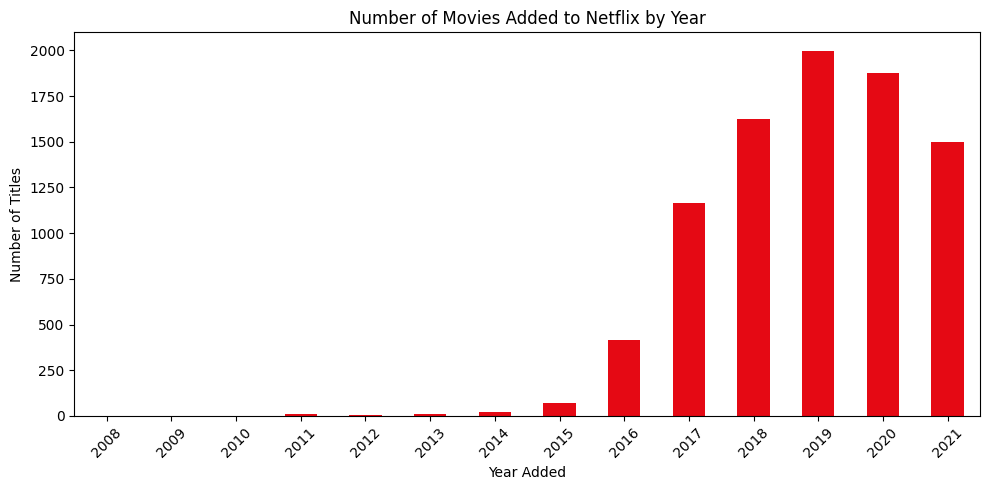

In [98]:

# Visualise catalogue additions over time
plt.figure(figsize=(10, 5))
titles_added_per_year.plot(kind="bar", color='#E50914')
plt.title("Number of Movies Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:

# Examine the original release year distribution to understand the age profile of the catalogue
release_year_counts = df_clean["release_year"].value_counts().sort_index()
release_year_counts.tail(20)


release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

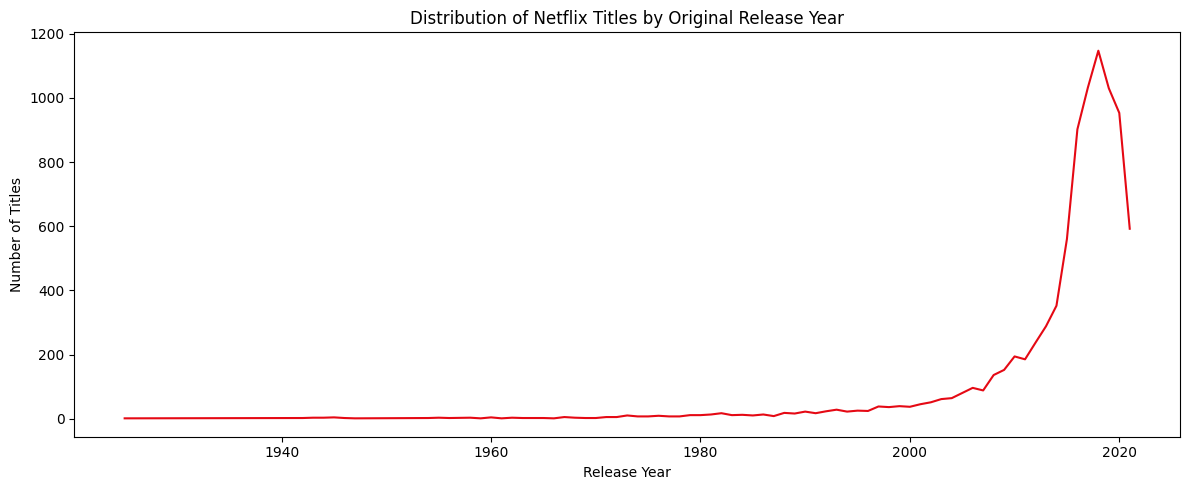

In [99]:

plt.figure(figsize=(12, 5))
release_year_counts.plot(kind="line", color='#E50914')
plt.title("Distribution of Netflix Titles by Original Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [ ]:

# Measure the gap between original release and Netflix addition
df_clean["years_to_add"] = df_clean["year_added"] - df_clean["release_year"]
df_clean[["title", "release_year", "year_added", "years_to_add"]].head()


,title,release_year,year_added,years_to_add
0,Dick Johnson Is Dead,2020,2021,1
1,Blood & Water,2021,2021,0
2,Ganglands,2021,2021,0
3,Jailbirds New Orleans,2021,2021,0
4,Kota Factory,2021,2021,0


In [58]:

# Summary statistics for the release-to-addition gap
df_clean["years_to_add"].describe()


count      8709.0
mean     4.690894
std      8.792208
min          -3.0
25%           0.0
50%           1.0
75%           5.0
max          93.0
Name: years_to_add, dtype: Float64

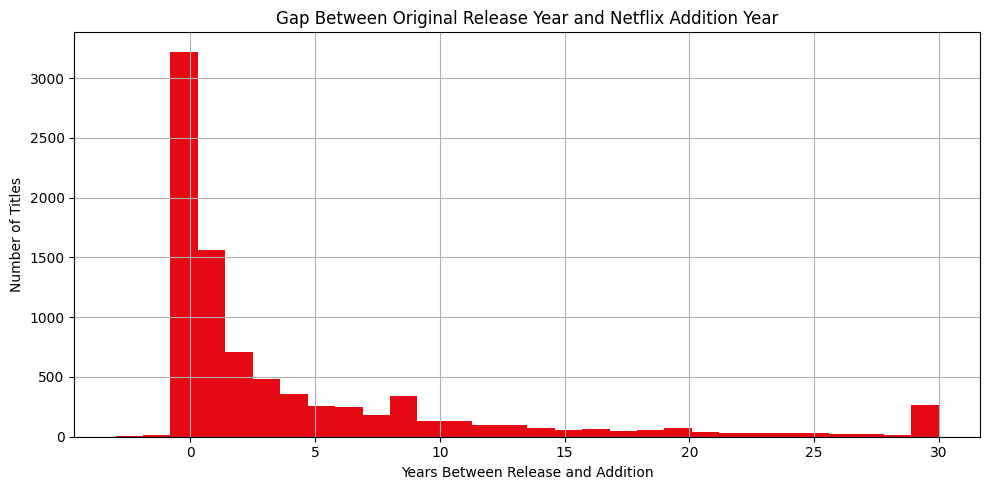

In [100]:

plt.figure(figsize=(10, 5))
df_clean["years_to_add"].dropna().clip(upper=30).hist(bins=30, color='#E50914')
plt.title("Gap Between Original Release Year and Netflix Addition Year")
plt.xlabel("Years Between Release and Addition")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [ ]:

# Inspect titles with negative timing gaps
negative_gap_titles = df_clean[df_clean["years_to_add"] < 0][["title", "type", "release_year", "year_added", "date_added"]]
negative_gap_titles


,title,type,release_year,year_added,date_added
1551,Hilda,TV Show,2021,2020,2020-12-14
1696,Polly Pocket,TV Show,2021,2020,2020-11-15
2920,Love Is Blind,TV Show,2021,2020,2020-02-13
3168,Fuller House,TV Show,2020,2019,2019-12-06
3287,Maradona in Mexico,TV Show,2020,2019,2019-11-13
3369,BoJack Horseman,TV Show,2020,2019,2019-10-25
3433,The Hook Up Plan,TV Show,2020,2019,2019-10-11
4844,Unbreakable Kimmy Schmidt,TV Show,2019,2018,2018-05-30
4845,Arrested Development,TV Show,2019,2018,2018-05-29
5394,Hans Teeuwen: Real Rancour,Movie,2018,2017,2017-07-01



#### Key Findings
- Netflix additions accelerated sharply from 2016 onward, pointing to a major catalogue expansion phase.
- Additions peaked in 2019, while the lower figure for 2021 should be interpreted carefully because the dataset ends in September 2021.
- The release-to-addition gap suggests that the catalogue is centred on relatively recent content, with a median gap of around **1 year**.
- The mean gap is higher than the median, which indicates a right-skewed distribution: most titles are added fairly soon after release, while a smaller number of much older titles create a longer tail.
- A small number of negative gaps appear in the data and likely reflect metadata inconsistencies rather than true early additions.



## No. 2: Movies vs TV Shows
This section examines whether Netflix expanded evenly across formats or remained more heavily weighted toward one type of content. The analysis looks at both absolute counts and yearly percentage shares so that growth and balance can be interpreted together.


In [61]:

# Overall format split
type_counts = df_clean["type"].value_counts()
type_counts


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [62]:

# Titles added by year and content type
titles_by_year_type = (
    df_clean.groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
)
titles_by_year_type


type,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,4
2014,19,4
2015,56,17
2016,253,165


In [63]:

# Convert yearly counts into shares so we can see whether the format mix changed over time
titles_by_year_type_pct = titles_by_year_type.div(titles_by_year_type.sum(axis=1), axis=0) * 100
titles_by_year_type_pct.round(2)


type,Movie,TV Show
year_added,,
2008,50.00,50.00
2009,100.00,0.00
2010,100.00,0.00
2011,100.00,0.00
2012,100.00,0.00
2013,60.00,40.00
2014,82.61,17.39
2015,76.71,23.29
2016,60.53,39.47


<Figure size 1000x500 with 0 Axes>

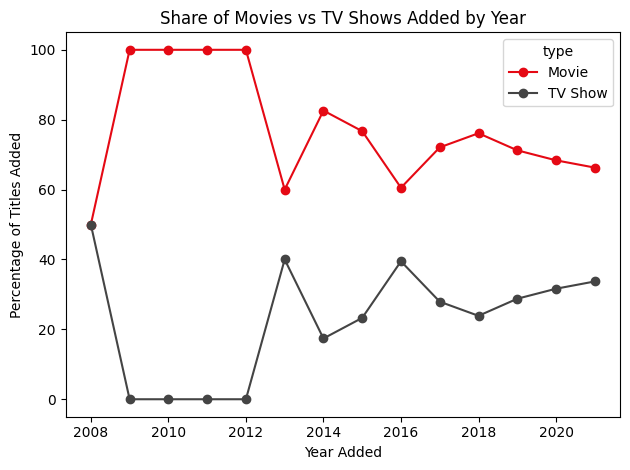

In [101]:

plt.figure(figsize=(10, 5))
titles_by_year_type_pct.plot(kind="line", marker="o", color=['#E50914', '#444444'])
plt.title("Share of Movies vs TV Shows Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Percentage of Titles Added")
plt.tight_layout()
plt.show()



### Key Findings
- Netflix's catalogue is clearly movie heavy overall, with movies outnumbering TV shows by a wide margin.
- Both formats expanded strongly during the main growth years, but movies remained the larger share throughout the period.
- Even so, TV shows gained a larger share of annual additions in later years, suggesting that series became a more important part of the platform's growth strategy over time.



## No. 3: Geographic Concentration and Country Representation
This section examines the `country` field to assess whether Netflix is broadly international or whether a relatively small set of countries contributes most of the catalogue. Because some titles are linked to multiple countries, results are interpreted as **country participation counts** rather than exclusive title totals.


In [65]:

# Top countries by recorded participation in the catalogue
top_countries = countries_exploded["country_name"].value_counts().head(15)
top_countries


country_name
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Name: count, dtype: int64

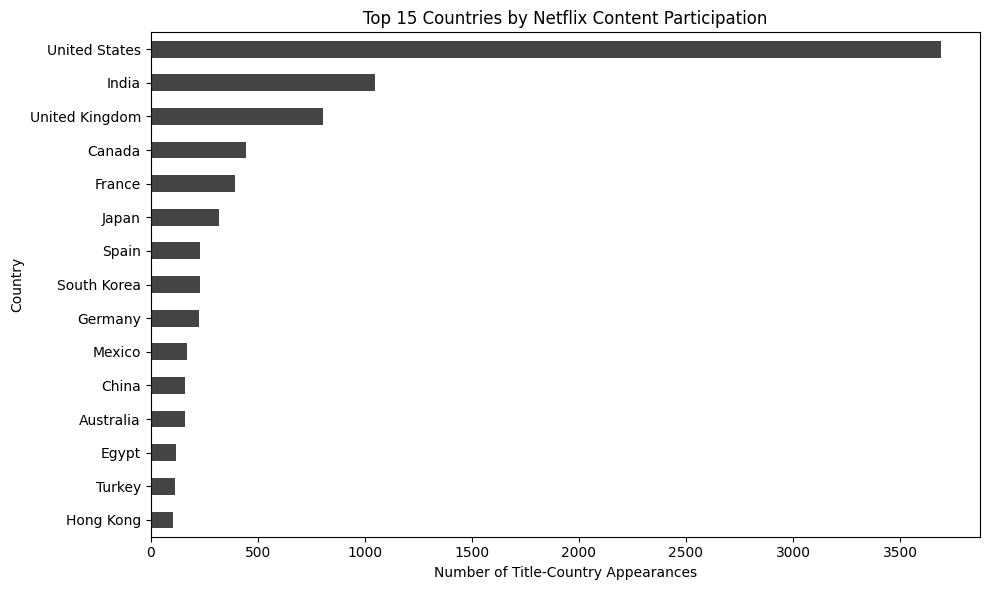

In [109]:

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh", color=['#444444'])
plt.title("Top 15 Countries by Netflix Content Participation")
plt.xlabel("Number of Title-Country Appearances")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [67]:

# Quantify how concentrated country participation is
country_counts = countries_exploded["country_name"].value_counts()
top_5_share = country_counts.head(5).sum() / country_counts.sum() * 100
top_10_share = country_counts.head(10).sum() / country_counts.sum() * 100

print("Top 5 country share:", round(top_5_share, 2), "%")
print("Top 10 country share:", round(top_10_share, 2), "%")


Top 5 country share: 63.68 %
Top 10 country share: 75.42 %


In [68]:

# Compare the top countries by content type to see whether countries contribute differently across formats
top_10_country_names = country_counts.head(10).index
country_type_table = (
    countries_exploded[countries_exploded["country_name"].isin(top_10_country_names)]
    .groupby(["country_name", "type"])
    .size()
    .unstack(fill_value=0)
)
country_type_table


type,Movie,TV Show
country_name,,
Canada,319,126
France,303,90
Germany,182,44
India,962,84
Japan,119,199
Mexico,111,58
South Korea,61,170
Spain,171,61
United Kingdom,532,272


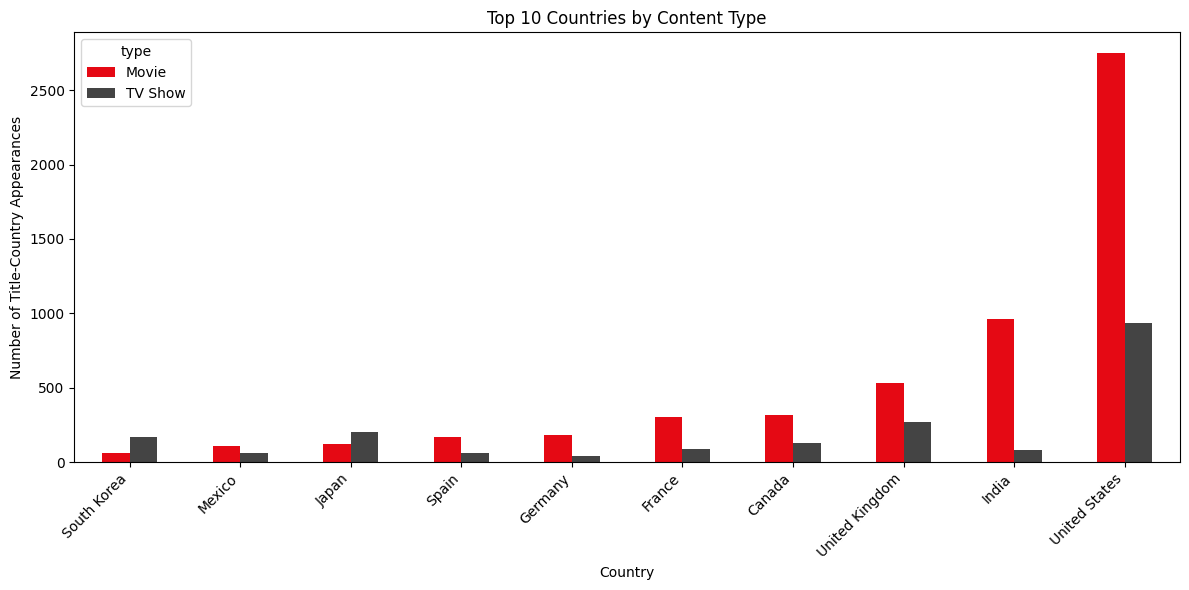

In [102]:

country_type_table.sort_values("Movie").plot(kind="bar", color=['#E50914', '#444444'], figsize=(12, 6))
plt.title("Top 10 Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Number of Title-Country Appearances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [70]:

# Share of movies vs TV shows within each top country
country_type_pct = country_type_table.div(country_type_table.sum(axis=1), axis=0) * 100
country_type_pct.round(2)


type,Movie,TV Show
country_name,,
Canada,71.69,28.31
France,77.10,22.90
Germany,80.53,19.47
India,91.97,8.03
Japan,37.42,62.58
Mexico,65.68,34.32
South Korea,26.41,73.59
Spain,73.71,26.29
United Kingdom,66.17,33.83



### Key Findings
- Netflix's catalogue is international in scope, but country participation is highly uneven.
- The United States dominates by a large margin, followed by India and the United Kingdom.
- The top 5 countries account for **63.68%** of all recorded country participation, and the top 10 account for **75.42%**, which shows that the catalogue is broad in appearance but concentrated beneath the surface.
- Country contributions are also structurally uneven by format: some countries are strongly movie led, while others such as Japan and South Korea contribute relatively more through TV content.



## No. 4: Category Concentration and Recurring Content Patterns
This section examines the `listed_in` field to assess whether Netflix's apparent variety is widely distributed or whether a smaller set of recurring labels dominates the catalogue. Because titles can carry multiple labels, results are interpreted as **category participation counts** rather than exclusive title totals.


In [71]:

# Top categories by recorded participation
top_categories = categories_exploded["category"].value_counts().head(15)
top_categories


category
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

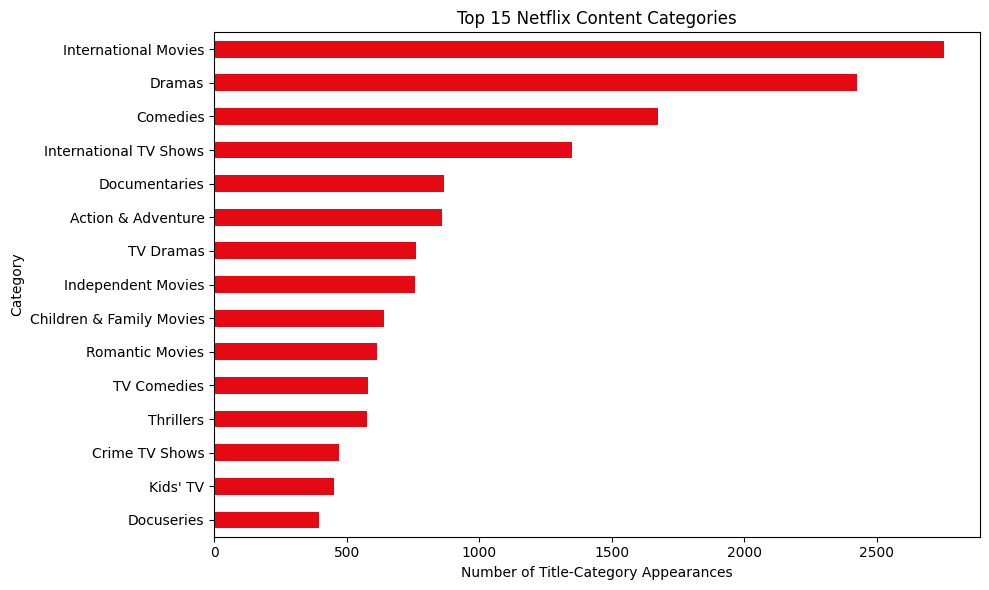

In [104]:

plt.figure(figsize=(10, 6))
top_categories.sort_values().plot(kind="barh", color=['#E50914'])
plt.title("Top 15 Netflix Content Categories")
plt.xlabel("Number of Title-Category Appearances")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [73]:

# Quantify concentration across category labels
category_counts = categories_exploded["category"].value_counts()
top_5_category_share = category_counts.head(5).sum() / category_counts.sum() * 100
top_10_category_share = category_counts.head(10).sum() / category_counts.sum() * 100

print("Top 5 category share:", round(top_5_category_share, 2), "%")
print("Top 10 category share:", round(top_10_category_share, 2), "%")


Top 5 category share: 46.95 %
Top 10 category share: 65.77 %


In [84]:

# Compare dominant categories across movies and TV shows
top_10_category_names = category_counts.head(20).index
category_type_table = (
    categories_exploded[categories_exploded["category"].isin(top_10_category_names)]
    .groupby(["category", "type"])
    .size()
    .unstack(fill_value=0)
)
category_type_table


type,Movie,TV Show
category,,
Action & Adventure,859,0
Children & Family Movies,641,0
Comedies,1674,0
Crime TV Shows,0,470
Documentaries,869,0
Docuseries,0,395
Dramas,2427,0
Horror Movies,357,0
Independent Movies,756,0


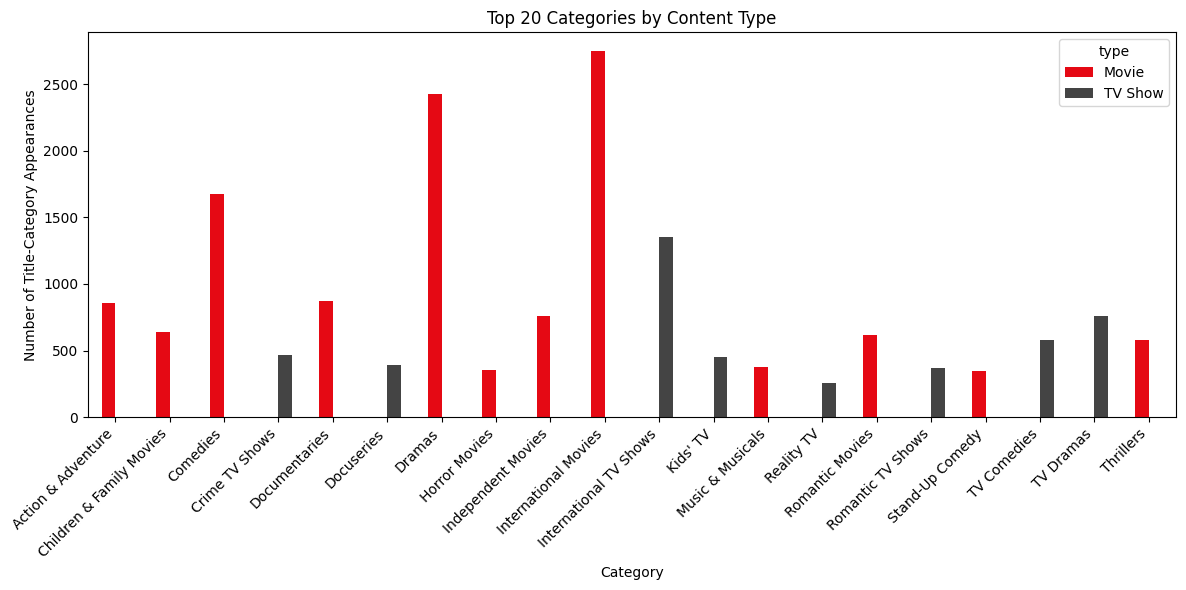

In [105]:

category_type_table.plot(kind="bar",color=['#E50914', '#444444'], figsize=(12, 6))
plt.title("Top 20 Categories by Content Type")
plt.xlabel("Category")
plt.ylabel("Number of Title-Category Appearances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



### Key Findings
- Category participation is concentrated in a relatively small set of labels.
- The top 5 categories account for **46.95%** of all category participation, and the top 10 account for **65.77%**.
- The largest labels include **International Movies**, **Dramas**, **Comedies**, and **International TV Shows**, which suggests the catalogue is not only genre clustered but also strongly framed through international classification labels.
- Movies and TV shows are structured differently, with many dominant labels being movie specific while TV content is concentrated in a smaller set of television specific labels.



## No. 6: Contributor Concentration
This section examines whether the catalogue is also concentrated at the contributor level. The focus is not on artistic importance or influence, but on **recorded appearance frequency** in the `director` and `cast` fields. Because these fields contain missing values and some titles include multiple names, results should be interpreted with caution.


In [86]:

# Top recorded directors
top_directors = directors_exploded["director_name"].value_counts().head(15)
top_directors


director_name
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Steven Spielberg       11
Don Michael Paul       10
David Dhawan            9
Yılmaz Erdoğan          9
Anurag Kashyap          9
Name: count, dtype: int64

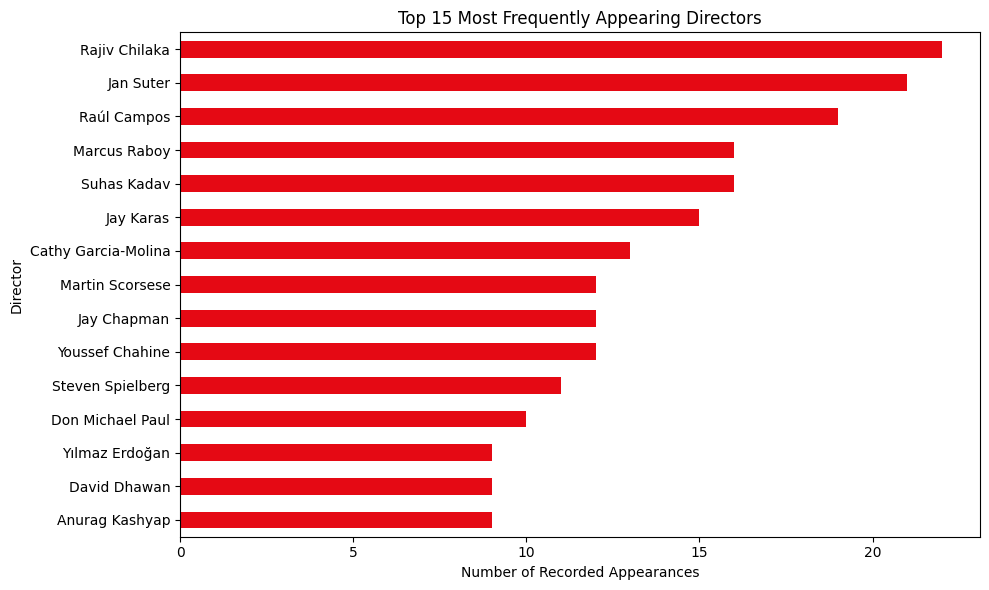

In [106]:

plt.figure(figsize=(10, 6))
top_directors.sort_values().plot(kind="barh", color=['#E50914'])
plt.title("Top 15 Most Frequently Appearing Directors")
plt.xlabel("Number of Recorded Appearances")
plt.ylabel("Director")
plt.tight_layout()
plt.show()


In [88]:

# Top recorded cast members
top_actors = cast_exploded["actor_name"].value_counts().head(15)
top_actors


actor_name
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Paresh Rawal        28
Boman Irani         27
Rajesh Kava         26
Vincent Tong        26
Andrea Libman       25
Name: count, dtype: int64

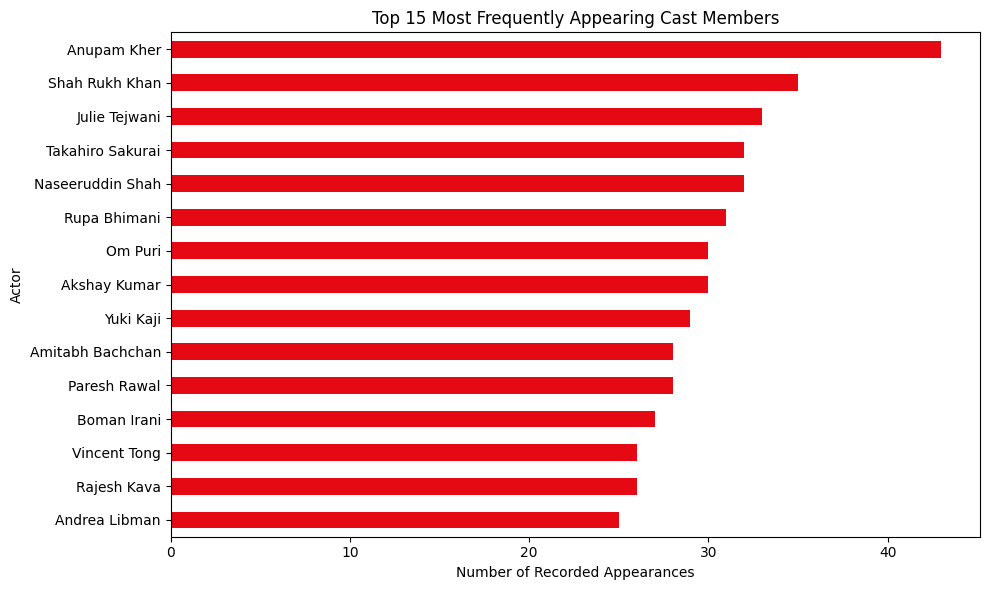

In [107]:

plt.figure(figsize=(10, 6))
top_actors.sort_values().plot(kind="barh", color=['#E50914'])
plt.title("Top 15 Most Frequently Appearing Cast Members")
plt.xlabel("Number of Recorded Appearances")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()


In [90]:

# Measure whether repeated names are structurally meaningful or just visible at the top
director_counts = directors_exploded["director_name"].value_counts()
actor_counts = cast_exploded["actor_name"].value_counts()

top_10_director_share = director_counts.head(10).sum() / director_counts.sum() * 100
top_20_director_share = director_counts.head(20).sum() / director_counts.sum() * 100

top_10_actor_share = actor_counts.head(10).sum() / actor_counts.sum() * 100
top_20_actor_share = actor_counts.head(20).sum() / actor_counts.sum() * 100

print("Top 10 director share:", round(top_10_director_share, 2), "%")
print("Top 20 director share:", round(top_20_director_share, 2), "%")
print("Top 10 actor share:", round(top_10_actor_share, 2), "%")
print("Top 20 actor share:", round(top_20_actor_share, 2), "%")


Top 10 director share: 2.26 %
Top 20 director share: 3.54 %
Top 10 actor share: 0.5 %
Top 20 actor share: 0.9 %



### Key Findings
- Some contributors do recur visibly in the catalogue, especially among directors and actors linked to strong regional content ecosystems.
- However, contributor concentration is weak at the overall catalogue level.
- The top 10 directors account for only **2.26%** of recorded director appearances, and the top 20 account for **3.54%**.
- The top 10 actors account for only **0.50%** of recorded cast appearances, and the top 20 account for **0.90%**.
- This suggests that Netflix's catalogue is more strongly concentrated across countries and category labels than across a small set of repeated creative names.



## No.5: Text Patterns and Recurring Description Themes
This section uses cleaned description text to identify the words and ideas that appear most often across the catalogue. The goal is not to measure audience sentiment, but to examine how Netflix content is described and framed.


In [91]:

# Build a focused custom stopword list
# This removes common filler words so the remaining terms are more theme revealing
stopwords_basic = {
    "the", "and", "a", "an", "of", "to", "in", "on", "for", "with", "at", "by",
    "from", "is", "it", "this", "that", "as", "his", "her", "their", "they",
    "he", "she", "them", "who", "into", "after", "when", "while", "but", "about",
    "against", "through", "out", "up", "down", "over", "under", "both", "one",
    "two", "three", "new", "life", "young", "former"
}

stopwords_expanded = stopwords_basic.union({
    "are", "him", "our", "your", "its", "must", "find", "finds", "found", "help",
    "where", "around", "before", "takes", "take", "gets", "get", "goes", "go",
    "tries", "try", "sets", "set", "faces", "face", "soon", "old", "back",
    "way", "ways", "comes", "come", "becomes", "become", "series", "story",
    "stories", "woman", "man"
})

stopwords_final = stopwords_expanded.union({
    "all", "has", "own", "more", "year", "years", "world", "other"
})


In [92]:

# Combine all cleaned descriptions into one word list and remove stopwords
all_description_words = " ".join(df_clean["description_clean"].dropna()).split()
filtered_description_words = [
    word for word in all_description_words
    if word not in stopwords_final and len(word) > 2
]

# Count the most common remaining words
description_word_counts = Counter(filtered_description_words)
description_words_df = pd.DataFrame(
    description_word_counts.most_common(20),
    columns=["word", "count"]
)
description_words_df


,word,count
0,family,635
1,love,504
2,friends,445
3,documentary,365
4,school,339
5,father,317
6,home,317
7,high,299
8,lives,277
9,group,266


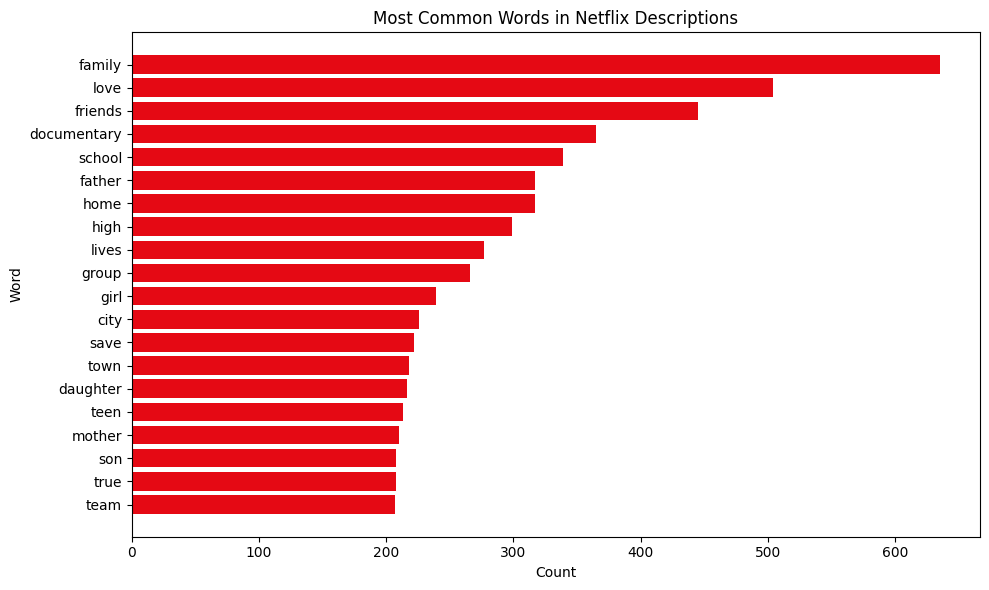

In [108]:

plt.figure(figsize=(10, 6))
plt.barh(description_words_df["word"][::-1], description_words_df["count"][::-1], color=['#E50914'])
plt.title("Most Common Words in Netflix Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()



### Key Findings
- Netflix descriptions are strongly human and relationship centred.
- The most common recurring words include **family**, **love**, **friends**, **father**, **daughter**, **mother**, **son**, and **home**, which suggests that many titles are framed through family dynamics, emotional relationships, and socially recognisable settings.
- Words such as **school**, **high**, **teen**, **girl**, and **group** point to a notable presence of youth centred and group based narratives.
- The prominence of **documentary** also shows that nonfiction content remains a visible part of how the catalogue is described.
- Overall, the text layer supports the broader idea that the catalogue is wide in volume but repeatedly framed through a smaller set of familiar human themes.



## 10. Final Conclusion
This analysis suggests that Netflix's catalogue is broad in scale, but not evenly distributed in structure. The platform expanded rapidly from 2016 onward, with growth driven primarily by movies, although TV shows became a more important share of annual additions over time.

Beneath that growth, the catalogue appears concentrated across both geography and content classification. A relatively small group of countries accounts for most recorded country participation, and a similarly limited set of category labels accounts for much of the catalogue's classification structure. This indicates that Netflix's variety is real, but not evenly spread. Instead, much of the library appears to be organised around a narrower set of dominant origins and recurring content patterns.

At the contributor level, repeated directors and actors are visible, but the overall contributor base remains widely dispersed. This suggests that concentration is expressed more strongly through country mix and category structure than through a small set of repeated creative names.

The text analysis adds a final interpretive layer. Netflix descriptions frequently emphasise family, love, friendship, school, home, and documentary storytelling, which suggests that much of the catalogue is framed through human relationships and socially recognisable settings. Taken together, these findings suggest that Netflix's catalogue is broad on the surface, but strategically concentrated beneath it, both in structure and in the recurring themes used to present its content.
